# VRPTW with IGS-BRKGA

Demonstrates **IGS-BRKGA** (IMAP Genetic Algorithm with Biased Random-Key encoding) on a Solomon 100-customer Vehicle Routing Problem with Time Windows (VRPTW) instance.

Tests are available at https://www.sintef.no/projectweb/top/vrptw/solomon-benchmark/. Add to data directory.

Three objectives are **minimised** simultaneously:

| Objective | Meaning |
|-----------|---------|
| `distance` | Total Euclidean route length |
| `n_vehicles` | Number of routes constructed |
| `route_balance` | Route-length imbalance (d_max − d_min) |

Preference-curve bounds are derived analytically from the instance structure using `compute_theoretical_bounds`.


## 1. Imports

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from pymoo.optimize import minimize as pymoo_minimize
from pymoo.termination import get_termination

# ── Resolve project root so both src/ and examples/VRPTW are on sys.path ──────
_HERE = Path(os.getcwd())
# If cwd is the notebook directory (examples/VRPTW), root is two levels up.
# If cwd is the project root, it contains src/.
if (_HERE / "src").exists():
    _ROOT = _HERE
elif (_HERE.parent / "src").exists():
    _ROOT = _HERE.parent
else:
    _ROOT = _HERE.parents[1]

_SRC = _ROOT / "src"

for _p in [str(_ROOT), str(_SRC)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from vrptw.data    import parse_solomon, compute_theoretical_bounds
from vrptw.decoder import VRPTWDecoder
from vrptw.igs_brkga_vrptw import IGSBRKGAVRPTWAlgorithm, VRPTWProblem
from utils.imap_helpers import build_imap_config, make_pref_cv

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
%matplotlib inline

print(f"Project root : {_ROOT}")
print("Imports OK")


Project root : c:\Users\leti\Documents\IGS-BRKGA
Imports OK


## 2. Configuration

Edit the cell below to choose the Solomon instance, decoder strategy, and run budget.

| Parameter | Description |
|-----------|-------------|
| `INSTANCE` | Solomon filename (without `.txt`) from the `data/` folder |
| `STRATEGY` | Decoder heuristic: `"i1"` \| `"i2"` \| `"i3"` \| `"savings"` \| `"nn"` \| `"sweep"` \| `"random"` |
| `N_GEN` | Number of generations |
| `POP_SIZE` | Population size |
| `SEED` | Random seed |

**Stakeholder configuration** — each stakeholder dict accepts:
- `obj_weights` — per-objective weight (must sum to 1, length == 3)
- `weight` — relative importance of this stakeholder
- `pref_shape` — `"linear"` \| `"convex"` \| `"concave"` \| `"sigmoid"`
- `reverse` — if `True`, flips the preference direction (higher objective = better)


In [2]:
# ── Instance ───────────────────────────────────────────────────────────────────
INSTANCE: str = "C101"   # Solomon filename (without .txt)
STRATEGY: str = "i1"     # Decoder strategy: "i1","i2","i3","savings","nn","sweep","random"

# ── Run budget ────────────────────────────────────────────────────────────────
N_GEN:    int = 50
POP_SIZE: int = 200
SEED:     int = 42

# ── BRKGA fractions ───────────────────────────────────────────────────────────
ELITE_FRACTION:  float = 0.15
MUTANT_FRACTION: float = 0.10
CROSSOVER_BIAS:  float = 0.70

# ── Stakeholder configuration ─────────────────────────────────────────────────
STAKEHOLDERS: list[dict] = [
    {
        "obj_weights": [1.0, 0.0, 0.0],
        "weight": 1/3,
        "pref_shape": "linear",
        "reversed": True,
    },
    {
        "obj_weights": [0.0, 1.0, 0.0],
        "weight": 1/3,
        "pref_shape": "linear",
    },
    {
        "obj_weights": [0.0, 0.0, 1.0],
        "weight": 1/3,
        "pref_shape": "linear",
    },
]

# ── Paths ─────────────────────────────────────────────────────────────────────
_DATA_DIR = _ROOT / "examples" / "VRPTW" / "data"

print(f"Instance : {INSTANCE}")
print(f"Strategy : {STRATEGY}")
print(f"N_GEN={N_GEN}  POP_SIZE={POP_SIZE}  SEED={SEED}")
print(f"Data dir : {_DATA_DIR}")


Instance : C101
Strategy : i1
N_GEN=50  POP_SIZE=200  SEED=42
Data dir : c:\Users\leti\Documents\IGS-BRKGA\examples\VRPTW\data


## 3. Problem Setup

Parse the Solomon instance, inspect its basic properties, and compute analytical lower/upper bounds for all three objectives — without evaluating any solutions.

| Bound | Method |
|-------|--------|
| `distance` lo | MST weight over depot + customers |
| `distance` hi | 2 × Σ d(depot, c) — one vehicle per customer |
| `n_vehicles` lo | ⌈Σ demand / capacity⌉ — bin-packing bound |
| `n_vehicles` hi | n_customers — absolute worst case |
| `route_balance` lo | 0 — all routes equal length |
| `route_balance` hi | 2 × (max depot-dist − min depot-dist) |


In [3]:
instance_path = _DATA_DIR / f"{INSTANCE}.txt"
instance = parse_solomon(instance_path)

print(f"Instance     : {instance.name}")
print(f"Customers    : {instance.n_customers}")
print(f"Fleet size   : {instance.n_vehicles} vehicles (max)")
print(f"Capacity     : {instance.capacity}")
print()

# ── Theoretical objective bounds ──────────────────────────────────────────────
OBJ_NAMES = ["distance", "n_vehicles", "route_balance"]

bounds = compute_theoretical_bounds(instance)
print(f"{'Objective':<15}  {'lo':>10}  {'hi':>10}")
print("-" * 40)
for obj in OBJ_NAMES:
    lo, hi = bounds[obj]
    print(f"{obj:<15}  {lo:>10.2f}  {hi:>10.2f}")


Instance     : C101
Customers    : 100
Fleet size   : 25 vehicles (max)
Capacity     : 200.0

Objective                lo          hi
----------------------------------------
distance             417.30     5770.96
n_vehicles            10.00      100.00
route_balance          0.00     1892.43


## 4. Preference Functions

IMAP aggregation converts raw objective values into preference scores in **[0, 100]**, where **higher is better**.

`build_imap_config` constructs the three structures required by `IGSBRKGAVRPTWAlgorithm`:
- `preference_functions` — per-stakeholder, per-objective callables
- `objective_weights` — per-stakeholder weight per objective
- `stakeholder_weights` — one weight per stakeholder (normalised internally)

A **constraint-violation preference function** (`make_pref_cv`) is also provided so that infeasible solutions (fleet size exceeded) are always deprioritised.


In [4]:
obj_bounds = [bounds[obj] for obj in OBJ_NAMES]

preference_functions, objective_weights, stakeholder_weights = build_imap_config(
    n_obj=len(OBJ_NAMES),
    obj_bounds=obj_bounds,
    obj_names=OBJ_NAMES,
    stakeholder_configs=STAKEHOLDERS,
)

cv_pref_fn = make_pref_cv()

print(f"{len(STAKEHOLDERS)} stakeholder(s) configured:")
for i, cfg in enumerate(STAKEHOLDERS, 1):
    print(
        f"  [{i}] weight={cfg['weight']:.2f}, obj_weights={cfg['obj_weights']}, "
        f"pref_shape={cfg.get('pref_shape', 'linear')}, "
        f"reverse={cfg.get('reverse', False)}"
    )


3 stakeholder(s) configured:
  [1] weight=0.33, obj_weights=[1.0, 0.0, 0.0], pref_shape=linear, reverse=False
  [2] weight=0.33, obj_weights=[0.0, 1.0, 0.0], pref_shape=linear, reverse=False
  [3] weight=0.33, obj_weights=[0.0, 0.0, 1.0], pref_shape=linear, reverse=False


### Preference curves (calibrated bounds)

{'obj_weights': [1.0, 0.0, 0.0], 'weight': 0.3333333333333333, 'pref_shape': 'linear', 'reversed': True}
{'obj_weights': [0.0, 1.0, 0.0], 'weight': 0.3333333333333333, 'pref_shape': 'linear'}
{'obj_weights': [0.0, 0.0, 1.0], 'weight': 0.3333333333333333, 'pref_shape': 'linear'}


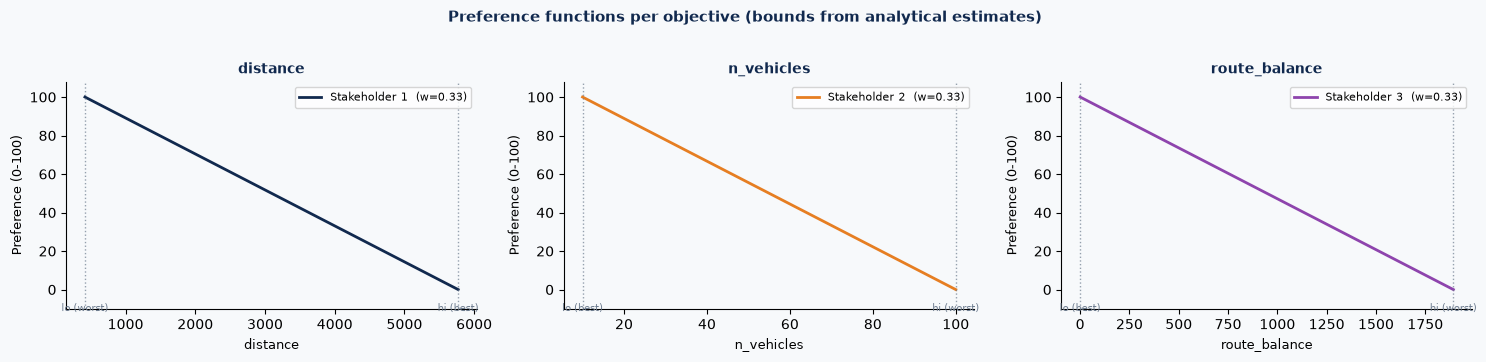

In [5]:
palette = ["#11294e", "#e67e22", "#8e44ad", "#27ae60"]

def _is_reversed(cfg: dict) -> bool:
    """Read the reverse flag from a stakeholder config (tolerates 'reversed' typo)."""
    print(cfg)
    return cfg.get("reversed", cfg.get("reversed", False))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

for j, (ax, obj) in enumerate(zip(axes, OBJ_NAMES)):
    lo, hi = bounds[obj]
    xs = np.linspace(lo, hi, 300)

    # Determine preference direction from the first active stakeholder for this objective
    active_cfg = next(
        (cfg for cfg in STAKEHOLDERS if cfg["obj_weights"][j] != 0.0), None
    )
    is_rev = _is_reversed(active_cfg) if active_cfg else False
    lo_label = "lo (worst)" if is_rev else "lo (best)"
    hi_label = "hi (best)"  if is_rev else "hi (worst)"

    for sid, cfg in enumerate(STAKEHOLDERS, 1):
        if cfg["obj_weights"][j] == 0.0:
            continue
        pf_fn = preference_functions[sid][obj]
        ys = [pf_fn(x) for x in xs]
        ax.plot(xs, ys, color=palette[(sid - 1) % len(palette)], linewidth=2,
                label=f"Stakeholder {sid}  (w={cfg['weight']:.2f})")

    for x_bound, lbl in [(lo, lo_label), (hi, hi_label)]:
        ax.axvline(x_bound, color="#6b7a8d", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(x_bound, -7, lbl, ha="center", va="top", fontsize=7, color="#6b7a8d")

    ax.set_xlabel(obj, fontsize=9)
    ax.set_ylabel("Preference (0-100)", fontsize=9)
    ax.set_title(f"{obj}", fontsize=10, fontweight="bold", color="#11294e")
    ax.set_ylim(-10, 108)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Preference functions per objective (bounds from analytical estimates)",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()


## 5. Run IGS-BRKGA

Configure and run **IGS-BRKGA** on the VRPTW problem.

Key parameters:
- `pop_size` — population size per generation
- `elite_fraction` — fraction kept as elite (inherits from BRKGA)
- `mutant_fraction` — fraction replaced by random immigrants
- `crossover_bias` — probability of inheriting from the elite parent
- `cv_pref_fn` / `cv_weight` — give 50 % of the aggregation weight to fleet-size feasibility, so solutions violating the fleet cap are always dominated by feasible ones


In [6]:
decoder = VRPTWDecoder(instance, strategy=STRATEGY)
problem = VRPTWProblem(instance, decoder)

algorithm = IGSBRKGAVRPTWAlgorithm(
    preference_functions=preference_functions,
    objective_weights=objective_weights,
    stakeholder_weights=stakeholder_weights,
    pop_size=POP_SIZE,
    elite_fraction=ELITE_FRACTION,
    mutant_fraction=MUTANT_FRACTION,
    crossover_bias=CROSSOVER_BIAS,
    cv_pref_fn=cv_pref_fn,
    cv_weight=0.5,
    verbose=True,
    seed=SEED,
)

t0 = time.perf_counter()
res = pymoo_minimize(
    problem,
    algorithm,
    get_termination("n_gen", N_GEN),
    seed=SEED,
    verbose=False,
    copy_algorithm=False,
)
wall_time = time.perf_counter() - t0

print(f"\nOptimisation complete in {wall_time:.1f}s")
print(f"Best solution found at generation : {res.algorithm.current_best_gen}")



Optimisation complete in 196.0s
Best solution found at generation : 1


In [7]:
# ── Extract best solution ─────────────────────────────────────────────────────
best = res.algorithm.current_best
best_F = best.get("F").flatten()
best_G = best.get("G").flatten()
cv = float(np.sum(np.maximum(0.0, best_G)))

best_distance, best_vehicles, best_balance = best_F
imap_score = float(best.get("imap_score"))

print(f"Best distance      : {best_distance:.2f}")
print(f"Best n_vehicles    : {int(best_vehicles)}")
print(f"Best route_balance : {best_balance:.2f}")
print(f"Constraint violation (fleet cap): {cv:.6f}  "
      f"{'✓ feasible' if cv <= 1e-9 else '✗ infeasible'}")
print(f"IMAP score         : {imap_score:.2f}")

# ── Decode the chromosome to get routes ───────────────────────────────────────
best_X = best.get("X").flatten()
best_sol = decoder.decode(best_X)

print(f"\nRoutes ({best_sol.n_vehicles} total):")
for k, route in enumerate(best_sol.routes, 1):
    route_dist = sum(
        instance.dist[route[i], route[i + 1]]
        for i in range(len(route) - 1)
    )
    print(f"  Route {k:>2}: {route}  (dist={route_dist:.2f})")


Best distance      : 852.95
Best n_vehicles    : 10
Best route_balance : 67.89
Constraint violation (fleet cap): 0.000000  ✓ feasible
IMAP score         : 100.00

Routes (10 total):
  Route  1: [0, 5, 3, 7, 8, 10, 11, 9, 6, 4, 2, 1, 75, 0]  (dist=59.62)
  Route  2: [0, 20, 24, 25, 27, 29, 30, 28, 26, 23, 22, 21, 47, 0]  (dist=75.63)
  Route  3: [0, 67, 65, 63, 62, 74, 72, 61, 64, 68, 66, 69, 0]  (dist=59.40)
  Route  4: [0, 43, 42, 41, 40, 44, 46, 45, 48, 51, 50, 52, 49, 0]  (dist=63.99)
  Route  5: [0, 90, 87, 86, 83, 82, 84, 85, 88, 89, 91, 0]  (dist=76.07)
  Route  6: [0, 98, 96, 95, 94, 92, 93, 97, 100, 99, 0]  (dist=95.94)
  Route  7: [0, 57, 55, 54, 53, 56, 58, 60, 59, 0]  (dist=101.88)
  Route  8: [0, 13, 17, 18, 19, 15, 16, 14, 12, 0]  (dist=95.88)
  Route  9: [0, 32, 33, 31, 35, 37, 38, 39, 36, 34, 0]  (dist=97.23)
  Route 10: [0, 81, 78, 76, 71, 70, 73, 77, 79, 80, 0]  (dist=127.30)


## 6. Results

### 6a. Hall-of-fame convergence

Each entry in the hall-of-fame is a solution that was IMAP-preferred at some point during the run. Tracking it shows how the algorithm improved over generations.


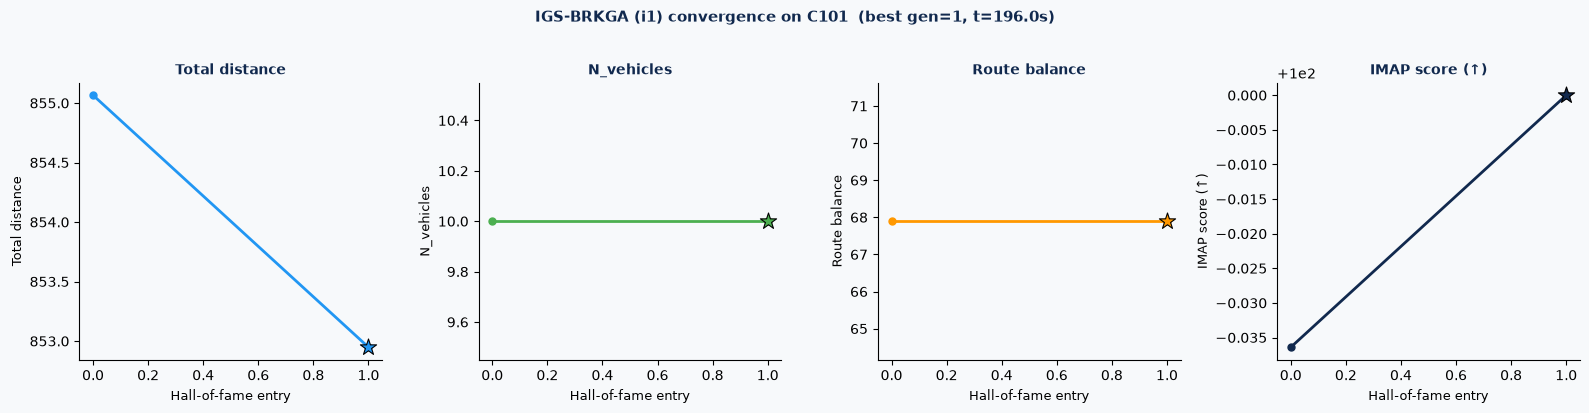

In [8]:
hof = res.algorithm.hall_of_fame  # list[Individual]

# Build arrays from the hall-of-fame + the final best solution
if hof:
    hof_F      = np.array([ind.get("F").flatten() for ind in hof])
    hof_scores = np.array([float(ind.get("imap_score")) for ind in hof])
else:
    hof_F      = np.empty((0, 3))
    hof_scores = np.empty(0)

# Append the current best as the last point
cb_F     = best_F.reshape(1, 3)
cb_score = np.array([imap_score])
all_F     = np.vstack([hof_F, cb_F]) if len(hof_F) else cb_F
all_scores = np.append(hof_scores, cb_score)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
obj_labels = ["Total distance", "N_vehicles", "Route balance", "IMAP score (↑)"]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#11294e"]

for ax, vals, label, color in zip(
    axes,
    [all_F[:, 0], all_F[:, 1], all_F[:, 2], all_scores],
    obj_labels,
    colors,
):
    xs = range(len(vals))
    ax.plot(xs, vals, color=color, linewidth=2, marker="o", markersize=5)
    ax.scatter([len(vals) - 1], [vals[-1]], s=150, color=color, marker="*",
               edgecolors="black", linewidths=0.8, zorder=5)
    ax.set_xlabel("Hall-of-fame entry", fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold", color="#11294e")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"IGS-BRKGA ({STRATEGY}) convergence on {INSTANCE}  "
    f"(best gen={res.algorithm.current_best_gen}, t={wall_time:.1f}s)",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()


### 6b. Best routes

Each route starts and ends at the depot (node 0). Routes are colour-coded.


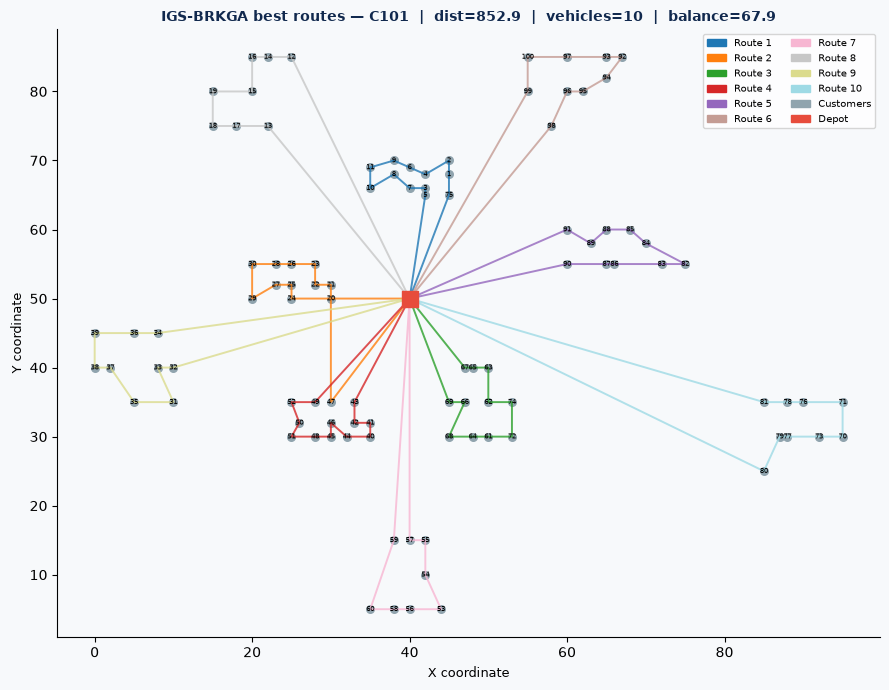

In [9]:
nodes = instance.nodes
xs = np.array([n.x for n in nodes])
ys = np.array([n.y for n in nodes])
depot = nodes[0]

n_routes = best_sol.n_vehicles
cmap = plt.get_cmap("tab20", max(n_routes, 1))

fig, ax = plt.subplots(figsize=(9, 7))

# ── Customer nodes ────────────────────────────────────────────────────────────
ax.scatter(xs[1:], ys[1:], s=30, color="#90a4ae", zorder=2, label="Customers")

# ── Depot ─────────────────────────────────────────────────────────────────────
ax.scatter([depot.x], [depot.y], s=120, color="#e74c3c", marker="s",
           zorder=5, label="Depot")

# ── Routes ────────────────────────────────────────────────────────────────────
legend_patches = []
for k, route in enumerate(best_sol.routes):
    color = cmap(k)
    rx = [nodes[i].x for i in route]
    ry = [nodes[i].y for i in route]
    ax.plot(rx, ry, color=color, linewidth=1.4, alpha=0.8, zorder=3)
    # Annotate customer nodes with their index
    for i in route[1:-1]:  # skip depot endpoints
        ax.annotate(str(i), (nodes[i].x, nodes[i].y),
                    fontsize=5, ha="center", va="center", color="black", zorder=6)
    patch = mpatches.Patch(color=color, label=f"Route {k + 1}")
    legend_patches.append(patch)

ax.legend(handles=legend_patches + [
    mpatches.Patch(color="#90a4ae", label="Customers"),
    mpatches.Patch(color="#e74c3c", label="Depot"),
], fontsize=7, loc="best", ncol=2)

ax.set_title(
    f"IGS-BRKGA best routes — {INSTANCE}  |  "
    f"dist={best_distance:.1f}  |  vehicles={int(best_vehicles)}  |  "
    f"balance={best_balance:.1f}",
    fontsize=10, fontweight="bold", color="#11294e",
)
ax.set_xlabel("X coordinate", fontsize=9)
ax.set_ylabel("Y coordinate", fontsize=9)
ax.set_facecolor("#f7f9fb")
ax.spines[["top", "right"]].set_visible(False)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()


### 6c. Preference scores

For each objective, the configured preference curves are plotted over the full bounds range. The ★ marks where the IMAP-selected best solution falls on each stakeholder's curve.


{'obj_weights': [1.0, 0.0, 0.0], 'weight': 0.3333333333333333, 'pref_shape': 'linear', 'reversed': True}
{'obj_weights': [0.0, 1.0, 0.0], 'weight': 0.3333333333333333, 'pref_shape': 'linear'}
{'obj_weights': [0.0, 0.0, 1.0], 'weight': 0.3333333333333333, 'pref_shape': 'linear'}


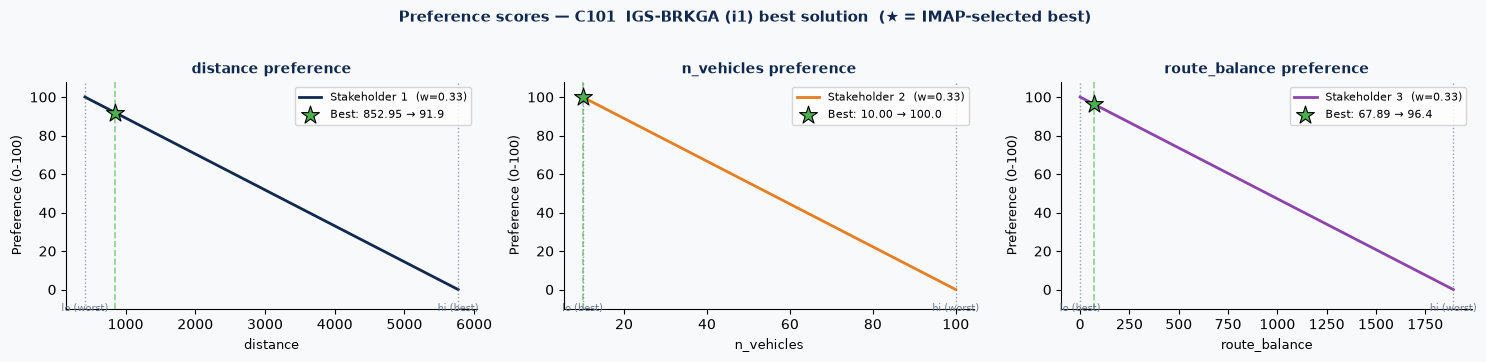


Per-stakeholder preference summary for the best solution:
  Stakeholder 1: distance=91.9, n_vehicles=100.0, route_balance=96.4  →  weighted=91.9
  Stakeholder 2: distance=91.9, n_vehicles=100.0, route_balance=96.4  →  weighted=100.0
  Stakeholder 3: distance=91.9, n_vehicles=100.0, route_balance=96.4  →  weighted=96.4

  IMAP score (pool-relative): 100.00


In [10]:
stake_palette = ["#11294e", "#e67e22", "#8e44ad", "#27ae60"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

for j, (ax, obj, raw_val) in enumerate(
    zip(axes, OBJ_NAMES, [best_distance, best_vehicles, best_balance])
):
    lo, hi = bounds[obj]
    xs = np.linspace(lo, hi, 300)

    # Active stakeholder = first one with non-zero weight for this objective
    active_sid = next(
        (sid for sid, cfg in enumerate(STAKEHOLDERS, 1) if cfg["obj_weights"][j] != 0.0),
        1
    )
    active_cfg = STAKEHOLDERS[active_sid - 1]
    is_rev = _is_reversed(active_cfg)
    lo_label = "lo (worst)" if is_rev else "lo (best)"
    hi_label = "hi (best)"  if is_rev else "hi (worst)"

    for sid, cfg in enumerate(STAKEHOLDERS, 1):
        if cfg["obj_weights"][j] == 0.0:
            continue
        pf_fn = preference_functions[sid][obj]
        ys = [pf_fn(x) for x in xs]
        ax.plot(xs, ys, color=stake_palette[(sid - 1) % len(stake_palette)],
                linewidth=2, label=f"Stakeholder {sid}  (w={cfg['weight']:.2f})")

    # ★ mark on the active stakeholder's curve
    best_pref = preference_functions[active_sid][obj](float(raw_val))
    ax.scatter([raw_val], [best_pref], s=180, color="#4CAF50", marker="*",
               edgecolors="black", linewidths=0.8, zorder=5,
               label=f"Best: {raw_val:.2f} → {best_pref:.1f}")
    ax.axvline(raw_val, color="#4CAF50", linestyle="--", linewidth=1.2,
               alpha=0.6, zorder=3)

    for x_bound, lbl in [(lo, lo_label), (hi, hi_label)]:
        ax.axvline(x_bound, color="#6b7a8d", linestyle=":", linewidth=1, alpha=0.7)
        ax.text(x_bound, -7, lbl, ha="center", va="top", fontsize=7, color="#6b7a8d")

    ax.set_xlabel(obj, fontsize=9)
    ax.set_ylabel("Preference (0-100)", fontsize=9)
    ax.set_title(f"{obj} preference", fontsize=10, fontweight="bold", color="#11294e")
    ax.set_ylim(-10, 108)
    ax.legend(fontsize=8, loc="upper right")
    ax.set_facecolor("#f7f9fb")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Preference scores — {INSTANCE}  IGS-BRKGA ({STRATEGY}) best solution  (★ = IMAP-selected best)",
    fontsize=11, fontweight="bold", color="#11294e", y=1.02,
)
fig.patch.set_facecolor("#f7f9fb")
fig.tight_layout()
plt.show()

print(f"\nPer-stakeholder preference summary for the best solution:")
for sid, cfg in enumerate(STAKEHOLDERS, 1):
    scores = [preference_functions[sid][obj](float(v))
              for obj, v in zip(OBJ_NAMES, [best_distance, best_vehicles, best_balance])]
    weighted = sum(w * s for w, s in zip(cfg["obj_weights"], scores))
    print(f"  Stakeholder {sid}: " +
          ", ".join(f"{obj}={s:.1f}" for obj, s in zip(OBJ_NAMES, scores)) +
          f"  →  weighted={weighted:.1f}")
print(f"\n  IMAP score (pool-relative): {imap_score:.2f}")
